In [35]:
from video_io import get_video_info, get_frames, trim_frames
from viz import show_frame, show_keypoints

### 1 Input

In [36]:
video_path = "../data/jessi-good-improved-quality.mp4"

In [37]:
import cv2
def get_video_fps(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return fps

In [38]:
fps = get_video_fps(video_path)

In [39]:
info = get_video_info(video_path)
frames = get_frames(video_path)
print(frames)

[array([[[232, 238, 241],
        [232, 238, 241],
        [232, 238, 241],
        ...,
        [104, 100,  97],
        [102,  98,  95],
        [103,  99,  96]],

       [[232, 238, 241],
        [232, 238, 241],
        [232, 238, 241],
        ...,
        [103,  99,  96],
        [102,  98,  95],
        [103,  99,  96]],

       [[232, 239, 242],
        [232, 239, 242],
        [232, 239, 242],
        ...,
        [103,  99,  96],
        [102,  98,  95],
        [102,  98,  95]],

       ...,

       [[122, 117, 117],
        [120, 115, 115],
        [118, 112, 114],
        ...,
        [240, 245, 249],
        [240, 245, 249],
        [240, 245, 249]],

       [[119, 115, 115],
        [117, 112, 112],
        [113, 109, 109],
        ...,
        [226, 232, 236],
        [226, 232, 236],
        [226, 232, 236]],

       [[112, 108, 108],
        [110, 105, 105],
        [109, 104, 104],
        ...,
        [208, 214, 217],
        [208, 214, 217],
        [208, 214, 217]

In [40]:
#frames = frames[:83]  # up to and including index 76

### 2 Perception

In [41]:
from ultralytics import YOLO
pose_model = YOLO("yolo26n-pose.pt")

In [42]:
processed_frames = pose_model.predict(frames, conf=0.25, verbose=False)
print(processed_frames)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[232, 238, 241],
        [232, 238, 241],
        [232, 238, 241],
        ...,
        [104, 100,  97],
        [102,  98,  95],
        [103,  99,  96]],

       [[232, 238, 241],
        [232, 238, 241],
        [232, 238, 241],
        ...,
        [103,  99,  96],
        [102,  98,  95],
        [103,  99,  96]],

       [[232, 239, 242],
        [232, 239, 242],
        [232, 239, 242],
        ...,
        [103,  99,  96],
        [102,  98,  95],
        [102,  98,  95]],

       ...,

       [[122, 117, 117],
        [120, 115, 115],
        [118, 112, 114],
        ...,
        [240, 245, 249],
        [240, 245, 249],
        [240, 245, 249]],

       [[119, 115, 115],
        [117, 112, 112],
        [113, 109, 109],
        ...,
        [22

### 3 Signal

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ankle_coords(x_raw, y_raw, x_smooth, y_smooth, label="Ankle"):
    """
    Plot raw vs smoothed X/Y coordinates for a single ankle on one graph.

    Parameters:
        x_raw, y_raw       : raw (pre-interpolation/smoothing) coordinate arrays
        x_smooth, y_smooth : smoothed coordinate arrays
        label               : e.g. "Left Ankle" or "Right Ankle" (used in title)
    """
    frames = np.arange(len(x_smooth))

    plt.figure(figsize=(12, 5))

    # Raw (faded, background)
    plt.plot(frames, x_raw, alpha=0.3, color="tab:blue", linestyle="--", label="Raw X")
    plt.plot(frames, y_raw, alpha=0.3, color="tab:orange", linestyle="--", label="Raw Y")

    # Smoothed (main lines)
    plt.plot(frames, x_smooth, color="tab:blue", linewidth=2, label="Smoothed X")
    plt.plot(frames, y_smooth, color="tab:orange", linewidth=2, label="Smoothed Y")

    plt.xlabel("Frame")
    plt.ylabel("Pixel coordinate")
    plt.title(f"{label} Coordinates (Raw vs Smoothed)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [44]:
import numpy as np
from scipy.signal import savgol_filter

# YOLO keypoint indices (COCO format): 15 = left ankle, 16 = right ankle
LEFT_ANKLE, RIGHT_ANKLE = 15, 16

def extract_keypoint_coords(processed_frames, keypoint_idx, conf_thresh=0.5):
    """Pull x, y, conf for one ankle across all frames."""
    xs, ys, confs = [], [], []
    for result in processed_frames:
        if result.keypoints is None or len(result.keypoints.xy) == 0:
            xs.append(np.nan); ys.append(np.nan); confs.append(0)
            continue
        kp_xy = result.keypoints.xy[0]      # first detected person
        kp_conf = result.keypoints.conf[0]  # per-keypoint confidence

        x, y = kp_xy[keypoint_idx].tolist()
        c = kp_conf[keypoint_idx].item()

        if c < conf_thresh:
            xs.append(np.nan); ys.append(np.nan)  # mark low-confidence as missing
        else:
            xs.append(x); ys.append(y)
        confs.append(c)
    return np.array(xs), np.array(ys), np.array(confs)


def interpolate_missing(coords, label="coords"):
    """Fill NaNs (low-confidence/missing detections) via linear interpolation."""
    coords = coords.copy()
    nans = np.isnan(coords)
    n_missing = nans.sum()
    print(f"{label}: {n_missing} / {len(coords)} points interpolated "
          f"({n_missing/len(coords)*100:.1f}%)")
    if nans.any():
        idx = np.arange(len(coords))
        coords[nans] = np.interp(idx[nans], idx[~nans], coords[~nans])
    return coords


def smooth_coords(coords, window_length=7, polyorder=2):
    """Savitzky-Golay smoothing. window_length must be odd and > polyorder."""
    window_length = min(window_length, len(coords) if len(coords) % 2 == 1 else len(coords) - 1)
    return savgol_filter(coords, window_length=window_length, polyorder=polyorder)


In [45]:
import matplotlib.pyplot as plt
import numpy as np

def plot_both_ankles(x_smooth_L, y_smooth_L, x_smooth_R, y_smooth_R):
    """
    Plot smoothed X/Y coordinates for both ankles on one combined graph.

    Parameters:
        x_smooth_L, y_smooth_L : smoothed left ankle coordinate arrays
        x_smooth_R, y_smooth_R : smoothed right ankle coordinate arrays
    """
    frames = np.arange(len(x_smooth_L))

    plt.figure(figsize=(12, 5))

    # Left ankle
    plt.plot(frames, x_smooth_L, color="tab:blue", linewidth=2, label="Left Ankle X")
    # plt.plot(frames, y_smooth_L, color="tab:cyan", linewidth=2, label="Left Ankle Y")

    # Right ankle
    plt.plot(frames, x_smooth_R, color="tab:red", linewidth=2, label="Right Ankle X")
    # plt.plot(frames, y_smooth_R, color="tab:orange", linewidth=2, label="Right Ankle Y")

    plt.xlabel("Frame")
    plt.ylabel("Pixel coordinate")
    plt.title("Left vs Right Ankle Coordinates (Smoothed)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Left ankle X: 0 / 157 points interpolated (0.0%)
Left ankle Y: 0 / 157 points interpolated (0.0%)
Right ankle X: 0 / 157 points interpolated (0.0%)
Right ankle Y: 0 / 157 points interpolated (0.0%)


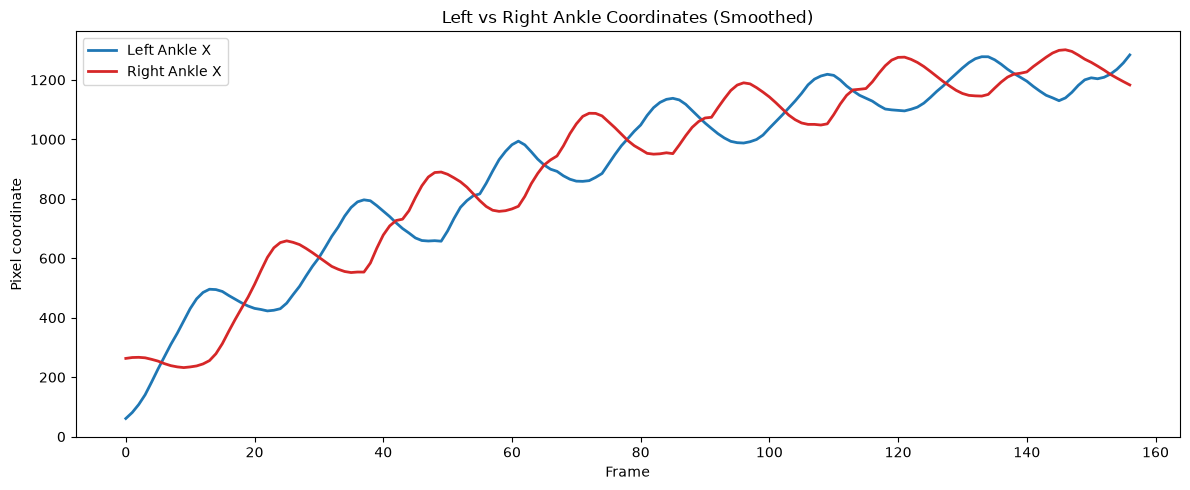

In [46]:
# Left ankle
x_raw_ankle_L, y_raw_ankle_L, conf_ankle_L = extract_keypoint_coords(processed_frames, LEFT_ANKLE)
x_filled_ankle_L = interpolate_missing(x_raw_ankle_L, label="Left ankle X")
y_filled_ankle_L = interpolate_missing(y_raw_ankle_L, label="Left ankle Y")
x_smooth_ankle_L = smooth_coords(x_filled_ankle_L)
y_smooth_ankle_L = smooth_coords(y_filled_ankle_L)

# Right ankle
x_raw_ankle_R, y_raw_ankle_R, conf_ankle_R = extract_keypoint_coords(processed_frames, RIGHT_ANKLE)
x_filled_ankle_R = interpolate_missing(x_raw_ankle_R, label="Right ankle X")
y_filled_ankle_R = interpolate_missing(y_raw_ankle_R, label="Right ankle Y")
x_smooth_ankle_R = smooth_coords(x_filled_ankle_R)
y_smooth_ankle_R = smooth_coords(y_filled_ankle_R)

plot_both_ankles(x_smooth_ankle_L, y_smooth_ankle_L, x_smooth_ankle_R, y_smooth_ankle_R)

#### Calculate initial contacts

In [47]:
# use y_smooth_R & y_smooth_L
from scipy.signal import find_peaks
fps = get_video_fps(video_path)
right_contacts, _ = find_peaks(y_smooth_ankle_R, distance=fps * 0.4, prominence=15)
right_contacts # frame indizes of right foot contacts

array([  4,  27,  52,  74,  99, 124, 149])

In [48]:
left_contacts, _ = find_peaks(y_smooth_ankle_L, distance=fps * 0.4, prominence=15)
left_contacts # frame indizes of left foot contacts

array([ 15,  39,  61,  86, 110, 135])

In [49]:
import matplotlib.pyplot as plt
import math

def plot_frames_grid(frames, frame_indices, n_cols=5, figsize_per_cell=(4, 5), title_prefix=""):
    """
    Display a grid of frames, n_cols per row.

    frames: dict mapping frame_idx -> image (BGR, from cv2)
    frame_indices: list/array of frame indices to display
    n_cols: number of images per row
    """
    n = len(frame_indices)
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows)
    )
    axes = axes.flatten() if n > 1 else [axes]

    for ax, idx in zip(axes, frame_indices):
        frame = frames[idx]
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{title_prefix}Frame {idx}")
        ax.axis("off")

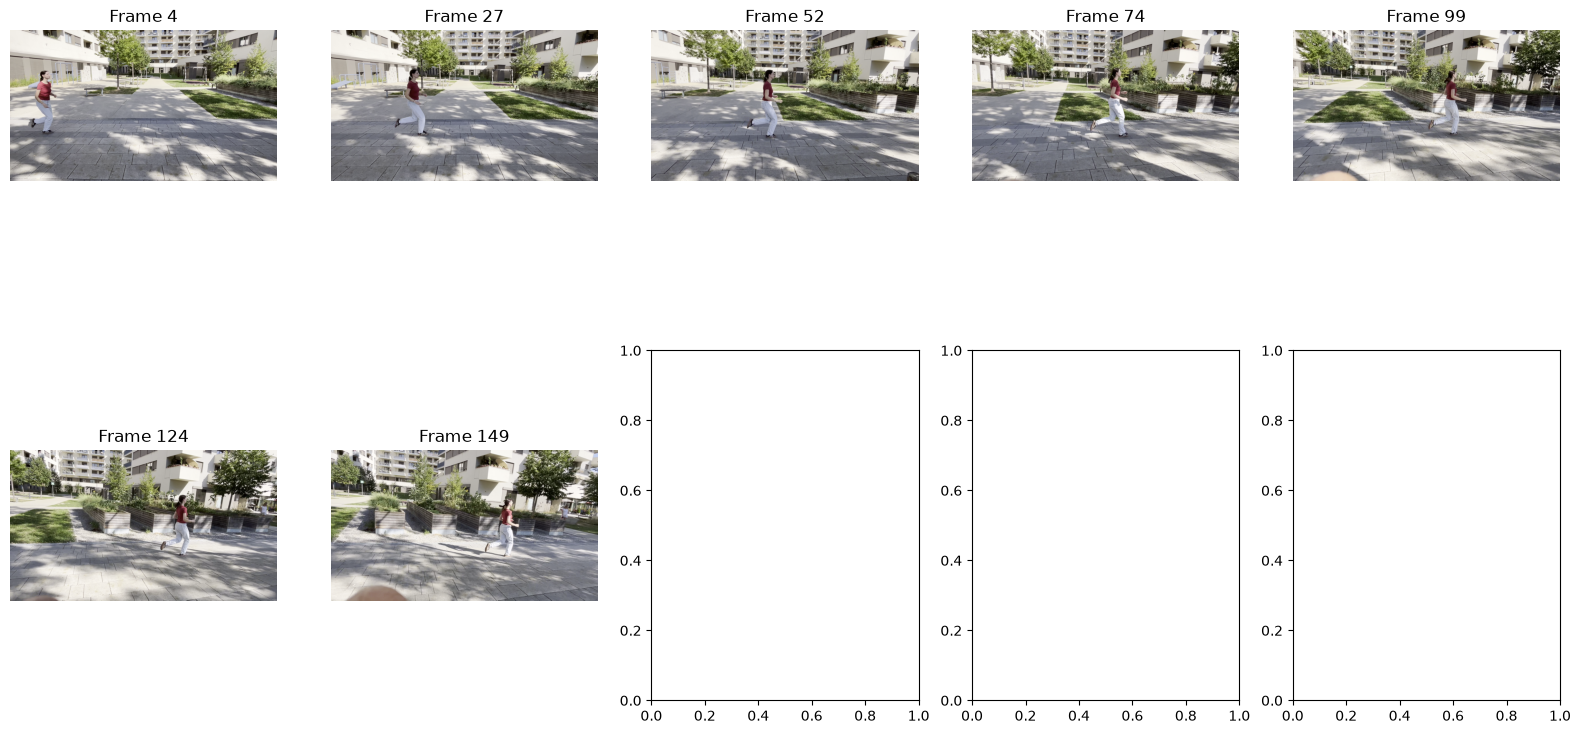

In [50]:
plot_frames_grid(frames, right_contacts)

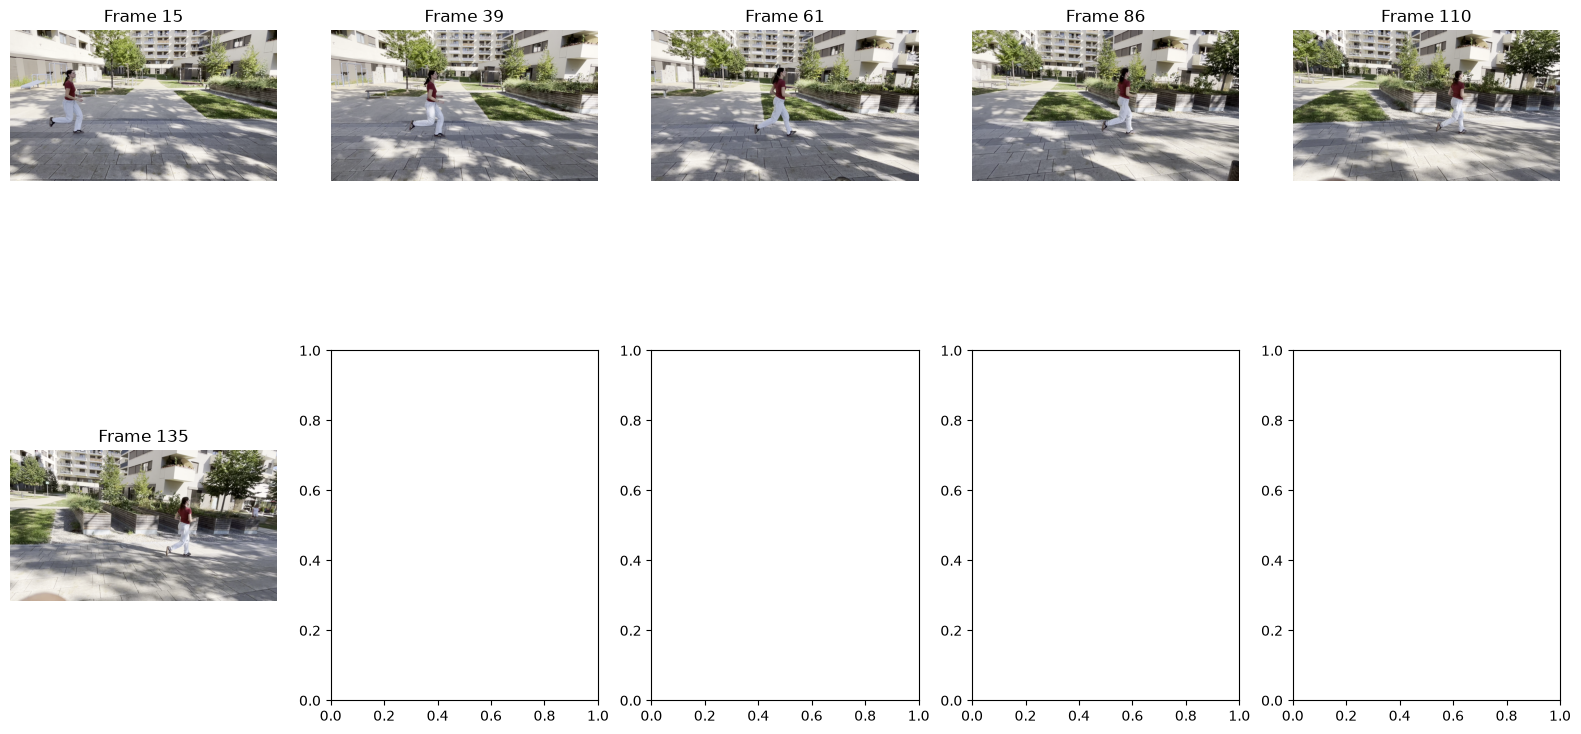

In [51]:
plot_frames_grid(frames, left_contacts)

#### Estimate stride timing from detected contacts

In [185]:
def estimate_stride_frames_from_contacts(contacts, fps):
    """
    Estimate the average stride frame gap from already-detected foot-contact
    peaks (left_contacts / right_contacts), instead of assuming a fixed cadence.

    Parameters:
        contacts : sorted array of frame indices for foot-contact events (one foot)
        fps      : frames per second

    Returns:
        avg_gap  : average number of frames between consecutive contacts
    """
    contacts = np.asarray(contacts)
    if len(contacts) < 2:
        raise ValueError("Need at least 2 contacts to estimate stride timing")

    avg_gap = np.mean(np.diff(contacts))
    cadence_spm = (fps / avg_gap) * 60
    print(f"Estimated {cadence_spm:.0f} contacts/min for this foot, avg gap: {avg_gap:.1f} frames")

    return avg_gap


In [186]:
# Derive an adaptive min_stride_frames per foot from the contacts we already detected,
# instead of relying on a fixed guess.
stride_frames_L = estimate_stride_frames_from_contacts(left_contacts, fps)
stride_frames_R = estimate_stride_frames_from_contacts(right_contacts, fps)

# Safety margin so a genuinely faster stride isn't rejected as "too close"
min_stride_frames_L = int(stride_frames_L * 0.7)
min_stride_frames_R = int(stride_frames_R * 0.7)


Estimated 93 contacts/min for this foot, avg gap: 19.3 frames
Estimated 111 contacts/min for this foot, avg gap: 16.2 frames


#### Calculate Toe-Offs

In [52]:
def compute_velocity(coords, fps):
    """First derivative — velocity in px/sec."""
    dt = 1 / fps
    velocity = np.gradient(coords, dt)
    return velocity

In [53]:
from scipy.signal import find_peaks
import numpy as np

def detect_toe_off_combined(y_smooth, fps, min_stride_frames=15,
                              velocity_thresh=None, confirm_window=8):
    """
    Detect toe-off by combining position minima (candidate stance points)
    with velocity threshold confirmation.

    Parameters:
        y_smooth          : smoothed ankle Y-coordinates (image coords, y increases downward)
        fps               : frames per second
        min_stride_frames : minimum frames between stance points (avoids double-counting
                             within one stride; tune based on expected cadence)
        velocity_thresh   : vertical velocity threshold for confirming liftoff;
                             auto-computed from data if None
        confirm_window    : how many frames after a candidate stance point to search
                             for the velocity confirmation

    Returns:
        toe_off_frames : indices of confirmed toe-off events
        candidates     : indices of candidate stance-phase minima (for diagnostics)
        velocity       : computed velocity array (for diagnostics/plotting)
    """
    velocity = compute_velocity(y_smooth, fps)

    if velocity_thresh is None:
        velocity_thresh = -0.5 * np.std(velocity)

    # Step 1: candidate stance points = local maxima in y (foot lowest = highest y value)
    candidates, _ = find_peaks(y_smooth, distance=min_stride_frames)

    # Step 2: confirm each candidate by checking for a velocity threshold
    # crossing (upward liftoff) within a short window afterward
    toe_off_frames = []
    for c in candidates:
        window_end = min(c + confirm_window, len(velocity))
        window = velocity[c:window_end]

        below_thresh = np.where(window < velocity_thresh)[0]
        if len(below_thresh) > 0:
            # first frame within the window where liftoff velocity is reached
            toe_off_frame = c + below_thresh[0]
            toe_off_frames.append(toe_off_frame)

    return np.array(toe_off_frames), candidates, velocity

In [54]:
fps = get_video_fps(video_path)
left_toe_offs, candidates_L, velocity_L = detect_toe_off_combined(
    y_smooth_ankle_L, fps=fps, min_stride_frames=min_stride_frames_L
)
print(f"Candidates found: {len(candidates_L)}, confirmed toe-offs: {len(left_toe_offs)}")
print(f"Left ankle toe-off at frames: {left_toe_offs}")

right_toe_offs, candidates_R, velocity_R = detect_toe_off_combined(
    y_smooth_ankle_R, fps=fps, min_stride_frames=min_stride_frames_R
)
print(f"Candidates found: {len(candidates_R)}, confirmed toe-offs: {len(right_toe_offs)}")
print(f"Right ankle toe-off at frames: {right_toe_offs}")


Candidates found: 6, confirmed toe-offs: 6
Left ankle toe-off at frames: [ 16  40  62  87 111 136]
Candidates found: 7, confirmed toe-offs: 7
Right ankle toe-off at frames: [  9  29  54  75 100 125 150]


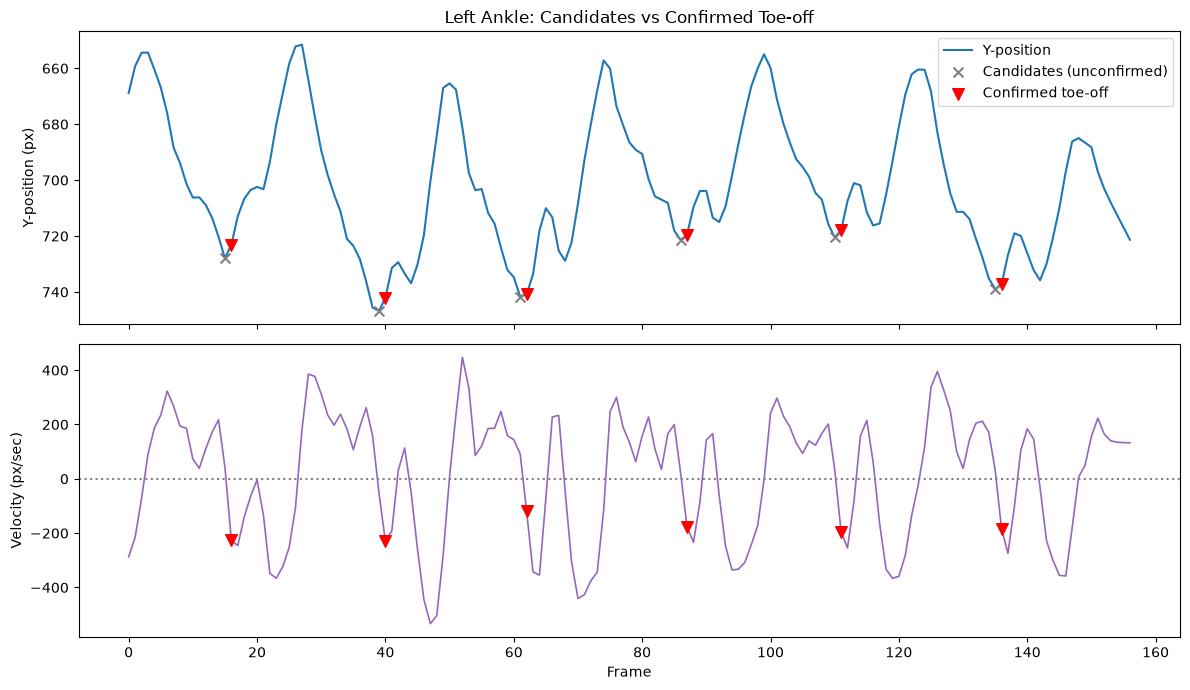

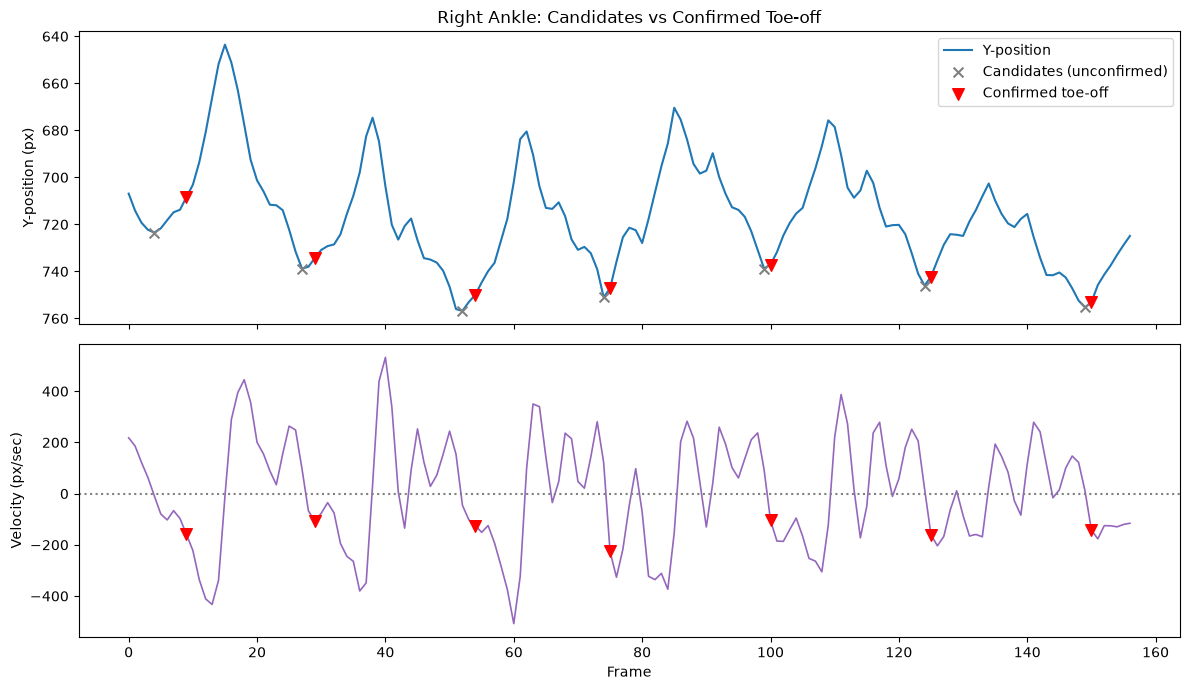

In [55]:
# Delete Later

def plot_toe_off_combined(y_smooth, candidates, toe_off_frames, velocity, label="Ankle"):
    frames = np.arange(len(y_smooth))
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(frames, y_smooth, color="tab:blue", label="Y-position")
    axes[0].scatter(candidates, y_smooth[candidates], color="gray", marker="x",
                     s=50, label="Candidates (unconfirmed)", zorder=4)
    axes[0].scatter(toe_off_frames, y_smooth[toe_off_frames], color="red", marker="v",
                     s=70, label="Confirmed toe-off", zorder=5)
    axes[0].invert_yaxis()
    axes[0].set_ylabel("Y-position (px)")
    axes[0].set_title(f"{label}: Candidates vs Confirmed Toe-off")
    axes[0].legend()

    axes[1].plot(frames, velocity, color="tab:purple", linewidth=1.2)
    axes[1].axhline(0, color="gray", linestyle=":")
    axes[1].scatter(toe_off_frames, velocity[toe_off_frames], color="red", marker="v", s=70, zorder=5)
    axes[1].set_ylabel("Velocity (px/sec)")
    axes[1].set_xlabel("Frame")

    plt.tight_layout()
    plt.show()

plot_toe_off_combined(y_smooth_ankle_L, candidates_L, left_toe_offs, velocity_L, label="Left Ankle")
plot_toe_off_combined(y_smooth_ankle_R, candidates_R, right_toe_offs, velocity_R, label="Right Ankle")

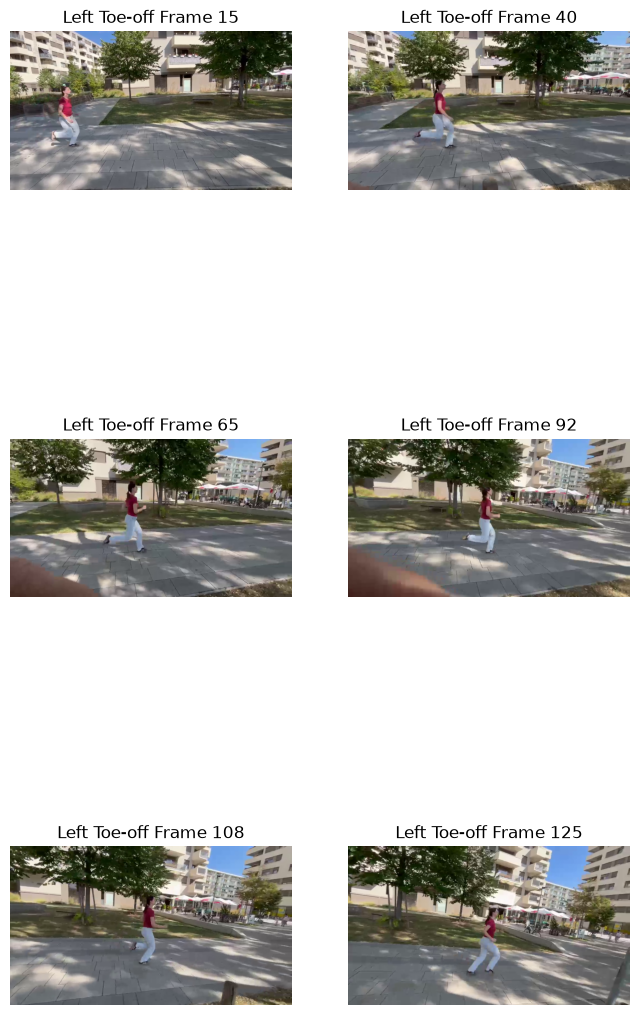

In [191]:
plot_frames_grid(frames, left_toe_offs, n_cols=2, title_prefix="Left Toe-off ")

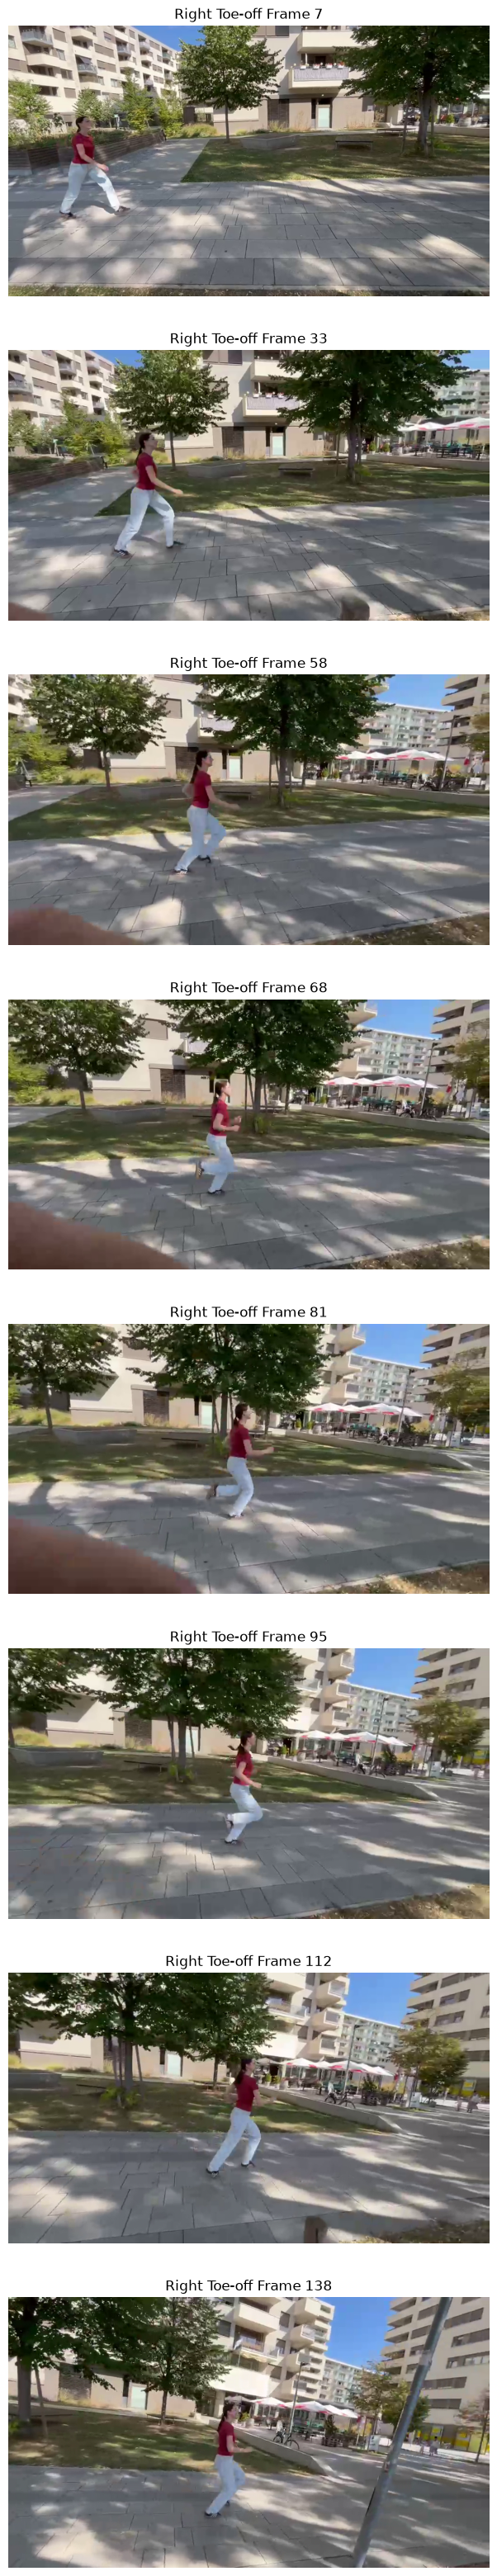

In [192]:
plot_frames_grid(frames, right_toe_offs, n_cols=1, figsize_per_cell=(10, 5), title_prefix="Right Toe-off ")

#### Build Segments

In [56]:
def build_gait_segments(contacts, toe_offs):
    """
    contacts: sorted array of frame indices for initial contact (per leg)
    toe_offs: sorted array of frame indices for toe-off (per leg)
    """
    contacts = sorted(contacts)
    toe_offs = sorted(toe_offs)

    stance_phases = []
    swing_phases = []
    stride_cycles = []

    # stance phase: each contact paired with the next toe_off after it
    for contact in contacts:
        # find first toe_off that comes after this contact
        next_toe_off = next((t for t in toe_offs if t > contact), None)
        if next_toe_off is not None:
            stance_phases.append((contact, next_toe_off))

    # swing phase: each toe_off paired with the next contact after it
    for toe_off in toe_offs:
        next_contact = next((c for c in contacts if c > toe_off), None)
        if next_contact is not None:
            swing_phases.append((toe_off, next_contact))

    # stride cycle: each contact paired with the next contact (same leg)
    for i in range(len(contacts) - 1):
        stride_cycles.append((contacts[i], contacts[i + 1]))

    return {
        "stance_phases": stance_phases,
        "swing_phases": swing_phases,
        "stride_cycles": stride_cycles,
    }

In [57]:
right_segments = build_gait_segments(right_contacts, right_toe_offs)
left_segments = build_gait_segments(left_contacts, left_toe_offs)

#### Height normalization

For Height normalization we calculate the distance between hip and ankle during ground contact.

In [58]:
# Extract Hip Keypoints
RIGHT_HIP = 12
LEFT_HIP = 11

# Left hip
x_raw_hip_L, y_raw_hip_L, conf_hip_L = extract_keypoint_coords(processed_frames, LEFT_HIP)
x_filled_hip_L = interpolate_missing(x_raw_hip_L, label="Left hip X")
y_filled_hip_L = interpolate_missing(y_raw_hip_L, label="Left hip Y")
x_smooth_hip_L = smooth_coords(x_filled_hip_L)
y_smooth_hip_L = smooth_coords(y_filled_hip_L)

# Right hip
x_raw_hip_R, y_raw_hip_R, conf_hip_R = extract_keypoint_coords(processed_frames, RIGHT_HIP)
x_filled_hip_R = interpolate_missing(x_raw_hip_R, label="Right hip X")
y_filled_hip_R = interpolate_missing(y_raw_hip_R, label="Right hip Y")
x_smooth_hip_R = smooth_coords(x_filled_hip_R)
y_smooth_hip_R = smooth_coords(y_filled_hip_R)

Left hip X: 0 / 157 points interpolated (0.0%)
Left hip Y: 0 / 157 points interpolated (0.0%)
Right hip X: 0 / 157 points interpolated (0.0%)
Right hip Y: 0 / 157 points interpolated (0.0%)


In [59]:
# Calculate Distance
def calculate_leg_length(hip_x, hip_y, ankle_x, ankle_y, contact_frames):
    lengths = []
    for frame in contact_frames:
        dx = ankle_x[frame] - hip_x[frame]
        dy = ankle_y[frame] - hip_y[frame]
        lengths.append(np.sqrt(dx**2 + dy**2))
    return np.mean(lengths)

In [60]:
right_leg_length_px = calculate_leg_length(
    x_smooth_hip_R, y_smooth_hip_R,
    x_smooth_ankle_R, y_smooth_ankle_R,
    right_contacts
)

left_leg_length_px = calculate_leg_length(
    x_smooth_hip_L, y_smooth_hip_L,
    x_smooth_ankle_L, y_smooth_ankle_L,
    left_contacts
)

print(f"Right leg length: {right_leg_length_px:.1f}px")
print(f"Left leg length: {left_leg_length_px:.1f}px")

Right leg length: 216.6px
Left leg length: 220.1px


7 % difference probably due to camera perspective, the right leg is in the front

In [61]:
import cv2
import matplotlib.pyplot as plt

def visualize_leg_length(video_path, frame_idx, hip_x, hip_y, ankle_x, ankle_y, leg_length_px, label=""):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Could not read frame {frame_idx}")
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    hx, hy = int(hip_x[frame_idx]), int(hip_y[frame_idx])
    ax, ay = int(ankle_x[frame_idx]), int(ankle_y[frame_idx])

    cv2.circle(frame_rgb, (hx, hy), 8, (255, 0, 0), -1)
    cv2.circle(frame_rgb, (ax, ay), 8, (0, 255, 0), -1)
    cv2.line(frame_rgb, (hx, hy), (ax, ay), (255, 255, 0), 2)

    plt.figure(figsize=(6, 8))
    plt.imshow(frame_rgb)
    plt.title(f"{label} — Frame {frame_idx}\nLeg length: {leg_length_px:.1f}px")
    plt.axis("off")
    plt.show()  # <-- this was missing

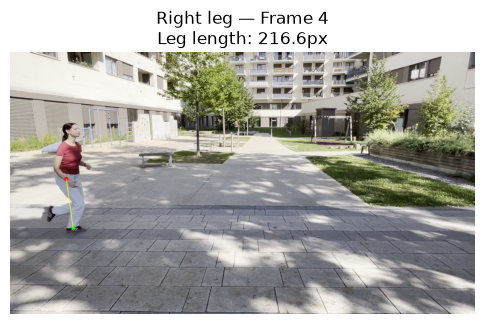

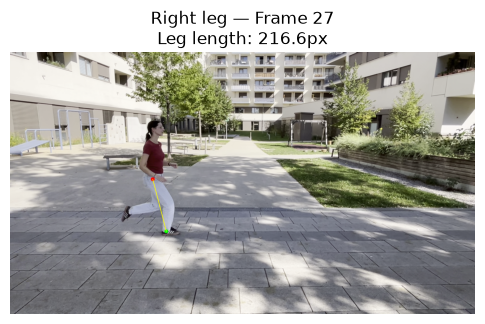

In [62]:
# example: pick two right-leg contact frames
example_frames = right_contacts[:2]  # first two contacts

for frame_idx in example_frames:
    visualize_leg_length(
        video_path, frame_idx,
        x_smooth_hip_R, y_smooth_hip_R,
        x_smooth_ankle_R, y_smooth_ankle_R,
        right_leg_length_px,
        label="Right leg"
    )

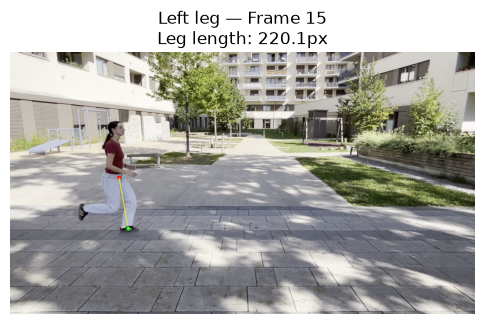

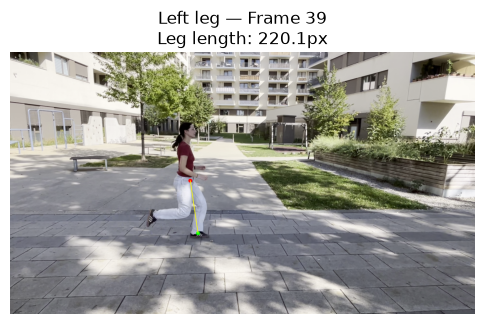

In [63]:
# example: pick two right-leg contact frames
example_frames = left_contacts[:2]  # first two contacts

for frame_idx in example_frames:
    visualize_leg_length(
        video_path, frame_idx,
        x_smooth_hip_L, y_smooth_hip_L,
        x_smooth_ankle_L, y_smooth_ankle_L,
        left_leg_length_px,
        label="Left leg"
    )

### 4 Logic

In [64]:
# Detect overstriding
def calculate_overstriding(ankle_x, hip_x, contact_frames, leg_length_px):
    results = []
    for frame in contact_frames:
        distance_px = ankle_x[frame] - hip_x[frame]
        normalized_distance = distance_px / leg_length_px
        results.append({
            "frame": frame,
            "distance_px": distance_px,
            "normalized_distance": normalized_distance
        })
    return results

right_overstride = calculate_overstriding(
    x_smooth_ankle_R, x_smooth_hip_R, right_contacts, right_leg_length_px
)

for r in right_overstride:
    print(r)

{'frame': np.int64(4), 'distance_px': np.float64(27.856788271949426), 'normalized_distance': np.float64(0.12861538121937377)}
{'frame': np.int64(27), 'distance_px': np.float64(56.47690545944954), 'normalized_distance': np.float64(0.2607550682026027)}
{'frame': np.int64(52), 'distance_px': np.float64(21.4470941452754), 'normalized_distance': np.float64(0.09902168773418901)}
{'frame': np.int64(74), 'distance_px': np.float64(51.878557477678896), 'normalized_distance': np.float64(0.23952439821720806)}
{'frame': np.int64(99), 'distance_px': np.float64(21.01292201450906), 'normalized_distance': np.float64(0.09701710581439998)}
{'frame': np.int64(124), 'distance_px': np.float64(7.815790085565595), 'normalized_distance': np.float64(0.036085668296436196)}
{'frame': np.int64(149), 'distance_px': np.float64(2.7243361700147943), 'normalized_distance': np.float64(0.012578317775025431)}


In [65]:
for r in right_overstride:
    print(r["frame"], round(r["distance_px"], 1), round(r["normalized_distance"], 3))

4 27.9 0.129
27 56.5 0.261
52 21.4 0.099
74 51.9 0.24
99 21.0 0.097
124 7.8 0.036
149 2.7 0.013


In [66]:
THRESHOLD = 0.15  # tune based on visual inspection

for r in right_overstride:
    r["overstriding"] = r["normalized_distance"] > THRESHOLD
    print(r["frame"], round(r["normalized_distance"], 3), "→", "OVERSTRIDING" if r["overstriding"] else "OK")

4 0.129 → OK
27 0.261 → OVERSTRIDING
52 0.099 → OK
74 0.24 → OVERSTRIDING
99 0.097 → OK
124 0.036 → OK
149 0.013 → OK


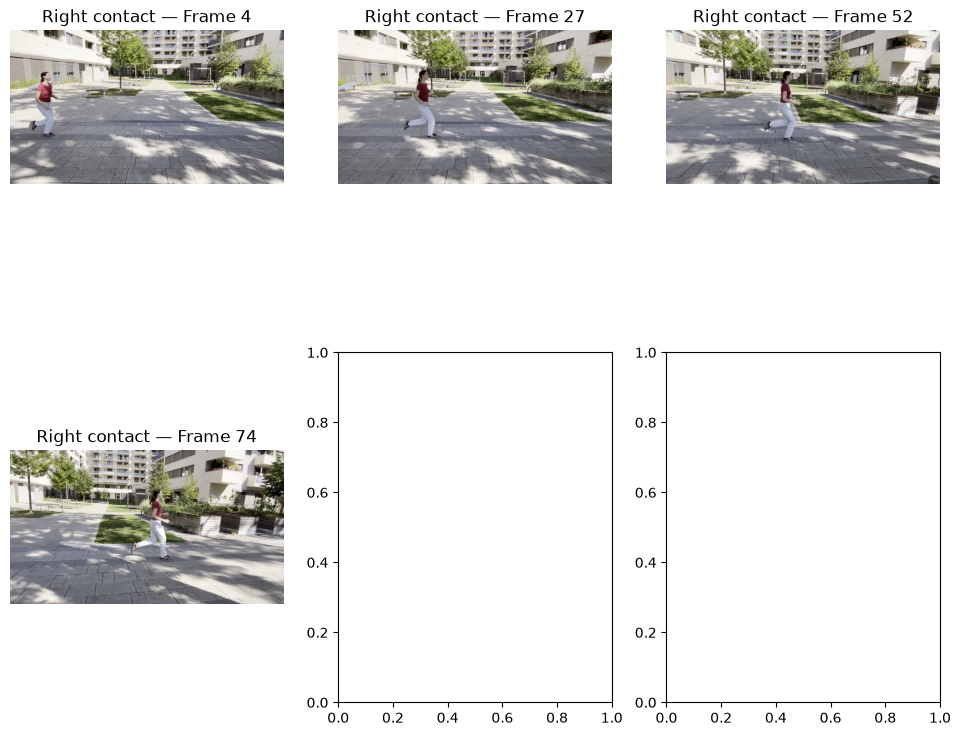

In [67]:
plot_frames_grid(frames, [4,27,52,74], n_cols=3, title_prefix="Right contact — ")